In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

In [20]:
df=pd.read_csv("Gaming and Mental Health.csv", index_col="record_id")
X=df.drop("gaming_addiction_risk_level", axis=1)
y=df["gaming_addiction_risk_level"]
X_train, y_train, X_test, y_test =train_test_split(X,y,random_state=7, train_size=0.85)

In [33]:
X

,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,...,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
record_id,,,,,,,,,,,,,,,,,,,,,
GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,...,False,True,True,False,6.8,3.7,7,1.3,383.70,3
GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,...,False,False,False,False,0.4,8.5,2,10.7,46.64,1
GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,...,True,True,False,True,1.8,7.1,5,3.2,100.81,6
GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,Poor,...,True,False,True,True,0.2,5.2,4,9.1,51.60,7
GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,Average,...,False,False,False,False,0.5,6.1,4,4.5,32.57,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,Average,...,False,True,True,True,1.9,7.5,6,2.4,426.54,3
GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,Excellent,...,False,False,True,False,2.1,7.7,1,10.9,83.71,7
GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,Poor,...,True,False,False,True,0.5,8.1,5,6.7,88.60,5


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, GD0001 to GD1000
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               1000 non-null   int64  
 1   gender                            1000 non-null   object 
 2   daily_gaming_hours                1000 non-null   float64
 3   game_genre                        1000 non-null   object 
 4   primary_game                      1000 non-null   object 
 5   gaming_platform                   1000 non-null   object 
 6   sleep_hours                       1000 non-null   float64
 7   sleep_quality                     1000 non-null   object 
 8   sleep_disruption_frequency        1000 non-null   object 
 9   academic_work_performance         1000 non-null   object 
 10  grades_gpa                        754 non-null    float64
 11  work_productivity_score           674 non-null    float64
 12  mood

In [22]:
X_numeic=X.select_dtypes(include=["int","float"])
numeric_cols=X_numeic.columns

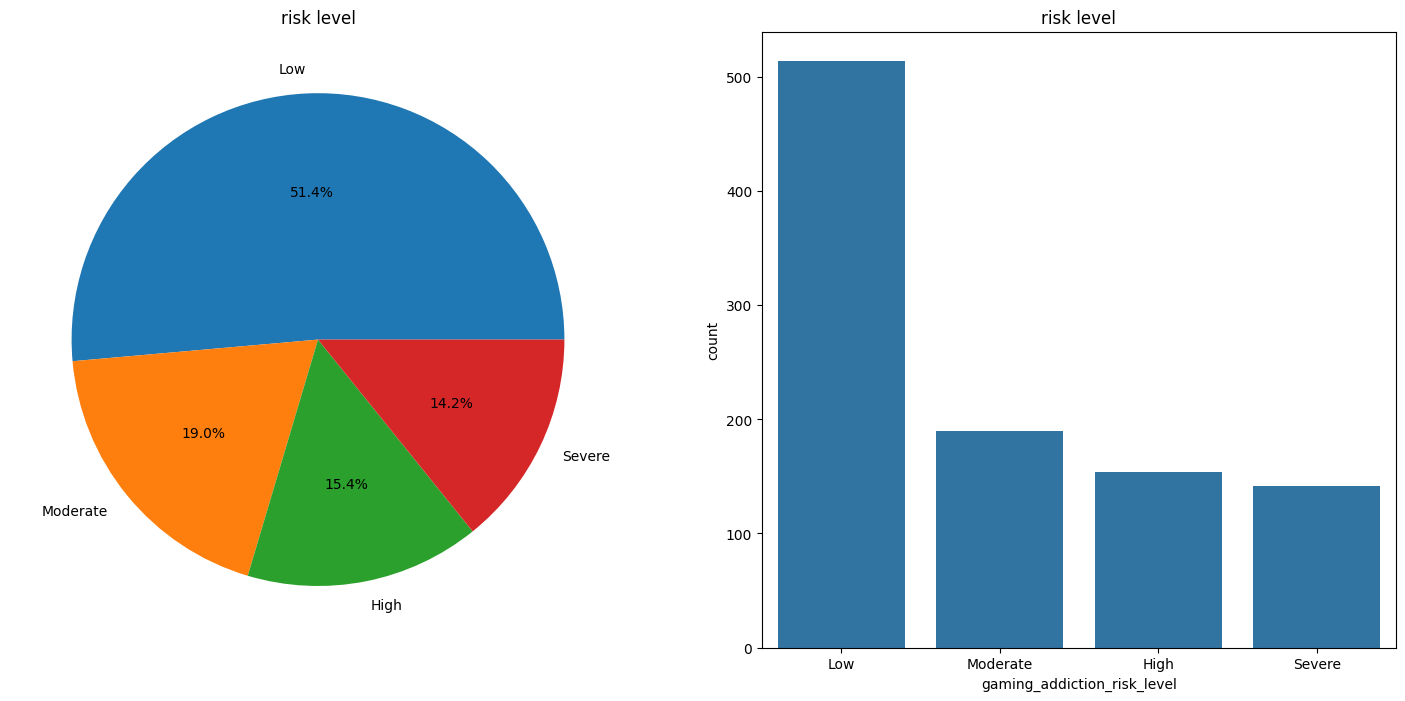

In [32]:
f,ax=plt.subplots(1,2,figsize=(18,8))
y.value_counts().plot.pie(autopct='%1.1f%%',ax=ax[0])
ax[0].set_title('risk level')
ax[0].set_ylabel('')
order=["Low", "Moderate", "High", "Severe"]
sns.countplot(x='gaming_addiction_risk_level',data=df,ax=ax[1],order=order)
ax[1].set_title('risk level')
plt.show()

In [ ]:
X["game_genre"].value_counts()

game_genre
MOBA             156
RPG              146
MMO              143
Battle Royale    141
Strategy         141
Mobile Games     139
FPS              134
Name: count, dtype: int64

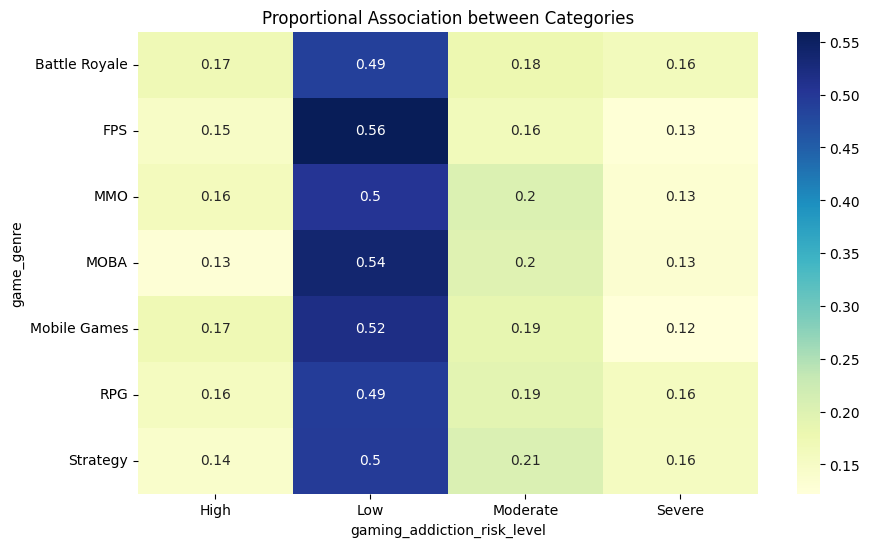

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Normalize by index to see percentages (how much of Cat A is also Cat B)
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df['game_genre'], df["gaming_addiction_risk_level"], normalize='index'), 
            annot=True, cmap="YlGnBu")
plt.title("Proportional Association between Categories")
plt.show()

In [42]:
X_numeic=X.select_dtypes(include=["int","float"])

df["gaming_addiction_risk_level"]=df["gaming_addiction_risk_level"].replace(["Low","Moderate", "High", "Severe"], [1,2,3,4])
df_numeic=df.select_dtypes(["int","float"])

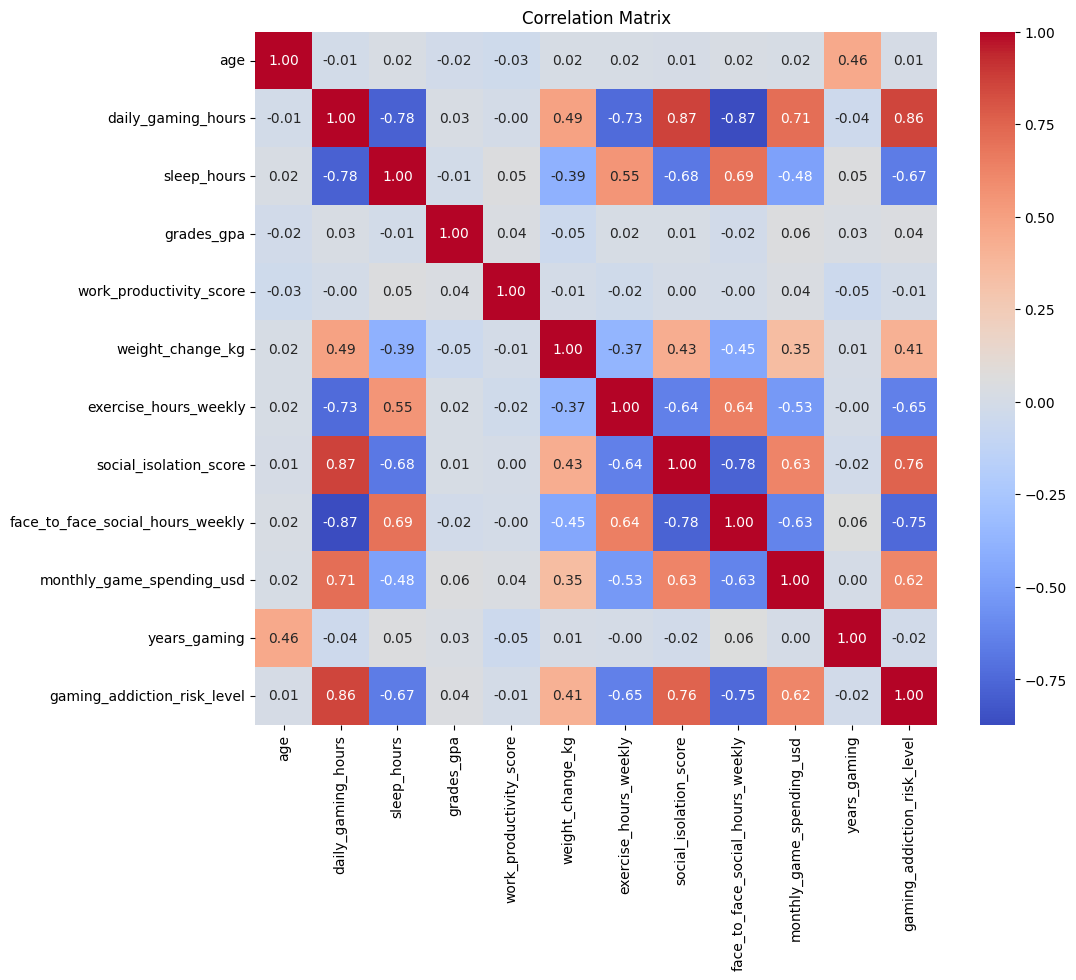

In [43]:
corr_matrix = df_numeic.corr(method='spearman')
figure, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()